# Training English Sentiment Model

IMDb binary sentiment. Classical NLP: `preprocess_english` (including contraction expansion) → TF-IDF / BoW → NB / LR / Linear SVM.

Reviews are grouped by **normalized** text before splitting. Conflicting labels on the same cleaned string are dropped; agreeing duplicates keep one row. Model selection uses the **validation** split. The vectorizer is fit on the inner training fold only. Test is scored once.

## 1. Imports

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
ROOT = Path("..") if (Path("..") / "data").exists() else Path(".")
sys.path.insert(0, str(ROOT.resolve()))

from src.English_model import (
    ENGLISH_FEATURE_NAMES,
    ENGLISH_MODEL_NAMES,
    EnglishSentimentModel,
    build_english_baseline,
    build_english_pipeline,
    make_classifier,
    make_vectorizer,
    save_english_model,
)
from src.labels import ENGLISH, NEGATIVE, POSITIVE, map_sentiment
from src.Preprocessing_pipeline import preprocess_english
from src.sentiment_dataset import resolve_normalized_labels, split_unique_normalized

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:.4f}".format)
LABELS = [NEGATIVE, POSITIVE]
print("wasn't ->", preprocess_english("The movie wasn't bad."))

wasn't -> the movie was not bad


## 2. Load Data

In [2]:
DATA = ROOT / "data" / "raw" / "english" / "MovieReviewTrainingDatabase.csv"
df = pd.read_csv(DATA)
print(DATA.resolve())
df.head()

/home/abdlrhman/Courses/IEEE SSCS/NLP/Week1/Project1/data/raw/english/MovieReviewTrainingDatabase.csv

,sentiment,review
0,Positive,"With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documenta..."
1,Positive,'The Classic War of the Worlds' by Timothy Hines is a very entertaining film that obviously goes to great effort and...
2,Negative,The film starts with a manager (Nicholas Bell) giving welcome investors (Robert Carradine) to Primal Park . A secret...
3,Negative,"It must be assumed that those who praised this film ('the greatest filmed opera ever,' didn't I read somewhere?) eit..."
4,Positive,"Superbly trashy and wondrously unpretentious 80's exploitation, hooray! The pre-credits opening sequences somewhat g..."


## 3. EDA

In [3]:
print("shape:", df.shape)
print("columns:", list(df.columns))
print(df["sentiment"].value_counts())
print(df.isnull().sum())
print("duplicate reviews:", int(df.duplicated(subset=["review"]).sum()))

fig, ax = plt.subplots(figsize=(5, 3))
df["sentiment"].value_counts().reindex(["Positive", "Negative"]).plot(
    kind="bar", ax=ax, color=["#2ca02c", "#d62728"], rot=0
)
ax.set_title("English class counts")
plt.tight_layout()
plt.close()

shape: (25000, 2)
columns: ['sentiment', 'review']
sentiment
Positive    12500
Negative    12500
Name: count, dtype: int64
sentiment    0
review       0
dtype: int64
duplicate reviews: 96


## 4. Cleaning

In [4]:
n0 = len(df)
df["label"] = df["sentiment"].map(lambda x: map_sentiment(x, ENGLISH))
df, prep_stats = resolve_normalized_labels(
    df, text_col="review", label_col="label", preprocess=preprocess_english
)
print("raw rows", n0)
print(prep_stats)
print(df["label"].value_counts())
assert set(df["label"]) == {POSITIVE, NEGATIVE}

raw rows 25000
{'n_raw': 25000, 'n_empty_normalized_dropped': 0, 'n_conflict_groups': 0, 'n_conflict_rows_dropped': 0, 'n_same_label_dups_dropped': 99, 'n_unique': 24901}
label
Positive    12470
Negative    12431
Name: count, dtype: int64


## 5. Preprocessing

Same `preprocess_english` used at inference (lowercase, URLs/HTML, contraction expansion, keep letters/digits).

**Conflict policy:** if two reviews become identical after cleaning and their labels disagree, drop every copy. If labels agree, keep one row. Splits then run on unique `clean_text` values.

In [5]:
print(df[["review", "clean_text", "label"]].head(2).assign(
    review=lambda x: x["review"].str.slice(0, 90),
    clean_text=lambda x: x["clean_text"].str.slice(0, 90),
))

                                                                                       review  \
0  With all this stuff going down at the moment with MJ i've started listening to his music,    
1  'The Classic War of the Worlds' by Timothy Hines is a very entertaining film that obviousl   

                                                                                   clean_text  \
0  with all this stuff going down at the moment with mj i have started listening to his music   
1  'the classic war of the worlds' by timothy hines is a very entertaining film that obviousl   

      label  
0  Positive  
1  Positive  


## 6. Train/Test Split

Group by unique normalized reviews, then split. Vectorizer fitting uses the inner `fit` fold only; the winner is refit on train+val.

In [6]:
fit, val, trainval, test, overlap = split_unique_normalized(df)
X_fit, y_fit = fit["clean_text"], fit["label"]
X_val, y_val = val["clean_text"], val["label"]
X_train, y_train = trainval["clean_text"], trainval["label"]
X_test, y_test = test["clean_text"], test["label"]
print("train", len(X_train), "val", len(X_val), "test", len(X_test))
print("normalized overlap", overlap)
assert overlap["train_test"] == 0

train 19920 val 3984 test 4981
normalized overlap {'fit_val': 0, 'fit_test': 0, 'val_test': 0, 'train_test': 0}


## 7. Feature Extraction

TF-IDF unigram, TF-IDF uni+bi, Bag of Words. Vectorizers are fitted on `X_fit` only during the grid.

## 8. Baseline Model

In [7]:
def scores(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=POSITIVE, zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label=POSITIVE, zero_division=0),
        "F1": f1_score(y_true, y_pred, pos_label=POSITIVE, zero_division=0),
    }

baseline = build_english_baseline()
baseline.fit(X_train, y_train)
base_pred = baseline.predict(X_test)
print(classification_report(y_test, base_pred, labels=LABELS, digits=4))
print(pd.Series(scores(y_test, base_pred), name="baseline"))

              precision    recall  f1-score   support

    Negative     0.9070    0.8822    0.8944      2487
    Positive     0.8856    0.9098    0.8975      2494

    accuracy                         0.8960      4981
   macro avg     0.8963    0.8960    0.8960      4981
weighted avg     0.8963    0.8960    0.8960      4981

Accuracy    0.8960
Precision   0.8856
Recall      0.9098
F1          0.8975
Name: baseline, dtype: float64


## 9. Model Experiments

Selection metric: binary F1 (Positive) on **validation**.

In [8]:
rows = []
for feature_name in ENGLISH_FEATURE_NAMES:
    vec = make_vectorizer(feature_name)
    Xtr = vec.fit_transform(X_fit)
    Xva = vec.transform(X_val)
    for model_name in ENGLISH_MODEL_NAMES:
        clf = make_classifier(model_name)
        clf.fit(Xtr, y_fit)
        pred = clf.predict(Xva)
        row = {"Model": model_name, "Features": feature_name, **scores(y_val, pred)}
        rows.append(row)
        print(f"val {model_name:20} {feature_name:24} F1={row['F1']:.4f}")

val_results = pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)
val_results

val Naive Bayes          TF-IDF unigram           F1=0.8497


val Logistic Regression  TF-IDF unigram           F1=0.8858


val Linear SVM           TF-IDF unigram           F1=0.8918


val Naive Bayes          TF-IDF unigram + bigram  F1=0.8716


val Logistic Regression  TF-IDF unigram + bigram  F1=0.8950


val Linear SVM           TF-IDF unigram + bigram  F1=0.9079


val Naive Bayes          Bag of Words             F1=0.8199


val Logistic Regression  Bag of Words             F1=0.8872


val Linear SVM           Bag of Words             F1=0.8675


,Model,Features,Accuracy,Precision,Recall,F1
0,Linear SVM,TF-IDF unigram + bigram,0.9076,0.9065,0.9093,0.9079
1,Logistic Regression,TF-IDF unigram + bigram,0.8938,0.8864,0.9038,0.8950
2,Linear SVM,TF-IDF unigram,0.8911,0.8870,0.8967,0.8918
3,Logistic Regression,Bag of Words,0.8870,0.8872,0.8872,0.8872
4,Logistic Regression,TF-IDF unigram,0.8848,0.8794,0.8922,0.8858
5,Naive Bayes,TF-IDF unigram + bigram,0.8722,0.8772,0.8662,0.8716
6,Linear SVM,Bag of Words,0.8672,0.8672,0.8677,0.8675
7,Naive Bayes,TF-IDF unigram,0.8544,0.8794,0.8221,0.8497
8,Naive Bayes,Bag of Words,0.8271,0.8568,0.7860,0.8199


## 10. Evaluation

validation winner: Linear SVM + TF-IDF unigram + bigram



Held-out TEST
              precision    recall  f1-score   support

    Negative     0.9030    0.8951    0.8990      2487
    Positive     0.8963    0.9042    0.9002      2494

    accuracy                         0.8996      4981
   macro avg     0.8997    0.8996    0.8996      4981
weighted avg     0.8996    0.8996    0.8996      4981

Accuracy    0.8996
Precision   0.8963
Recall      0.9042
F1          0.9002
Name: test, dtype: float64
Confusion matrix labels ['Negative', 'Positive']
[[2226  261]
 [ 239 2255]]


<Figure size 500x400 with 1 Axes>

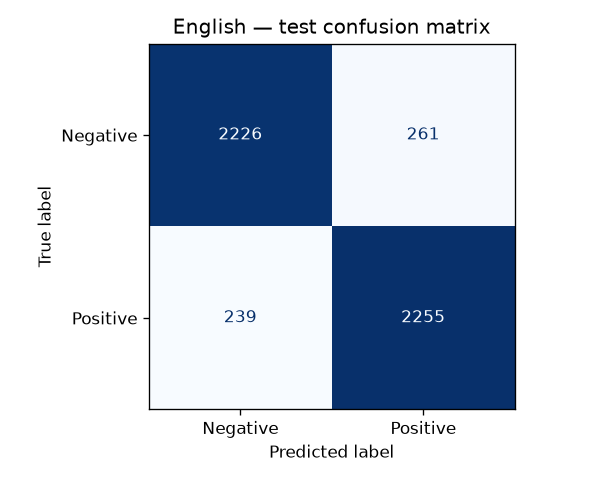

In [9]:
best_row = val_results.iloc[0]
best_model_name, best_feature_name = best_row["Model"], best_row["Features"]
print("validation winner:", best_model_name, "+", best_feature_name)

best = build_english_pipeline(best_feature_name, best_model_name)
best.fit(X_train, y_train)
y_pred = best.predict(X_test)
print("\nHeld-out TEST")
print(classification_report(y_test, y_pred, labels=LABELS, digits=4))
print(pd.Series(scores(y_test, y_pred), name="test"))

cm = confusion_matrix(y_test, y_pred, labels=LABELS)
print("Confusion matrix labels", LABELS)
print(cm)
fig, ax = plt.subplots(figsize=(5, 4))
from IPython.display import display
ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(cmap="Blues", ax=ax, colorbar=False)
ax.set_title("English — test confusion matrix")
plt.tight_layout()
display(fig)

Held-out test confusion matrix (`Negative`, `Positive`). Split on unique normalized reviews; train/test overlap **0**.

|  | Pred Negative | Pred Positive |
| :--- | ---: | ---: |
| **True Negative** | 2226 | 261 |
| **True Positive** | 239 | 2255 |

Accuracy **0.8996**. Positive F1 **0.9002**. Same-label normalized duplicates dropped: **99**. Conflicting groups: **0**.

## Error analysis

In [10]:
tmp = EnglishSentimentModel(best)
for text in (
    "The movie wasn't bad.",
    "Great, another terrible movie.",
    "This movie is not good.",
    "This movie was fantastic",
    "This movie was terrible",
):
    print(f"{tmp.predict(text):10}  {text}")

Negative    The movie wasn't bad.
Negative    Great, another terrible movie.
Negative    This movie is not good.
Positive    This movie was fantastic
Negative    This movie was terrible


## 11. Best Model

In [11]:
print(best)
print(best_row.to_dict())

Pipeline(steps=[('vec',
                 TfidfVectorizer(max_features=30000, ngram_range=(1, 2),
                                 token_pattern="(?u)\\b\\w+(?:'\\w+)?\\b")),
                ('clf', LinearSVC(max_iter=2000))])
{'Model': 'Linear SVM', 'Features': 'TF-IDF unigram + bigram', 'Accuracy': 0.9076305220883534, 'Precision': 0.9065467266366817, 'Recall': 0.9092731829573935, 'F1': 0.9079079079079079}


## 12. Save Model

In [12]:
path = save_english_model(best, ROOT / "models" / "English_model_weights.pkl")
print("saved", path.resolve())

saved /home/abdlrhman/Courses/IEEE SSCS/NLP/Week1/Project1/models/English_model_weights.pkl


## 13. Example Predictions

In [13]:
model = EnglishSentimentModel.load(path)
for text in (
    "I absolutely loved this movie.",
    "This was one of the worst movies I've ever watched.",
    "This movie was amazing.",
    "I hated every minute of it.",
):
    print(f"{model.predict(text):10}  {text}")

Positive    I absolutely loved this movie.
Negative    This was one of the worst movies I've ever watched.
Positive    This movie was amazing.
Negative    I hated every minute of it.
